# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid')

# LOAD DATA

In [40]:
df = pd.read_csv("Amazon Sale Report.csv", low_memory=False)

# DATA CLEANING

In [41]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.title()
)

df.columns

Index(['Index', 'Order_Id', 'Date', 'Status', 'Fulfilment', 'Sales_Channel',
       'Ship_Service_Level', 'Style', 'Sku', 'Category', 'Size', 'Asin',
       'Courier_Status', 'Qty', 'Currency', 'Amount', 'Ship_City',
       'Ship_State', 'Ship_Postal_Code', 'Ship_Country', 'Promotion_Ids',
       'B2B', 'Fulfilled_By', 'Unnamed:_22'],
      dtype='object')

In [42]:
important_cols = [
    'Order_Id','Date','Status','Fulfilment','Sales_Channel','Ship_Service_Level',
    'Category','Size','Courier_Status','Qty','Amount','Ship_City',
    'Ship_State','Ship_Postal_Code','B2B','Promotion_Ids'
]

important_cols = [c for c in important_cols if c in df.columns]

df = df[important_cols]

In [43]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')

df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [45]:
df['Amount'].fillna(0, inplace=True)
df['Qty'].fillna(0, inplace=True)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

In [46]:
df.drop_duplicates(inplace=True)

# FEATURE ENGINEERING

In [47]:
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month_name()

df['Day'] = df['Date'].dt.day

df['Weekday'] = df['Date'].dt.day_name()

In [49]:
df['Revenue'] = df['Qty'] * df['Amount']

In [50]:
df['High_Value_Order'] = np.where(df['Revenue'] > 1000, 'Yes', 'No')

In [51]:
df['Large_Size'] = np.where(df['Size'].isin(['XL','XXL','3XL','4XL']), 'Yes','No')

In [52]:
df['Promotion_Used'] = np.where(df['Promotion_Ids']!='Unknown','Yes','No')

In [53]:
df['Fast_Delivery'] = np.where(df['Ship_Service_Level']=='Expedited','Yes','No')

In [54]:
df['Weekend'] = np.where(df['Weekday'].isin(['Saturday','Sunday']),'Yes','No')

In [55]:
df.head()

,Order_Id,Date,Status,Fulfilment,Sales_Channel,Ship_Service_Level,Category,Size,Courier_Status,Qty,...,Year,Month,Day,Weekday,Revenue,High_Value_Order,Large_Size,Promotion_Used,Fast_Delivery,Weekend
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Set,S,Unknown,0,...,2022,April,30,Saturday,0.0,No,No,No,No,Yes
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,kurta,3XL,Shipped,1,...,2022,April,30,Saturday,406.0,No,Yes,Yes,No,Yes
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,kurta,XL,Shipped,1,...,2022,April,30,Saturday,329.0,No,Yes,Yes,Yes,Yes
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Western Dress,L,Unknown,0,...,2022,April,30,Saturday,0.0,No,No,No,No,Yes
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Top,3XL,Shipped,1,...,2022,April,30,Saturday,574.0,No,Yes,No,Yes,Yes


# Exploratory Data Analysis (EDA)

In [58]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 576x360 with 0 Axes>

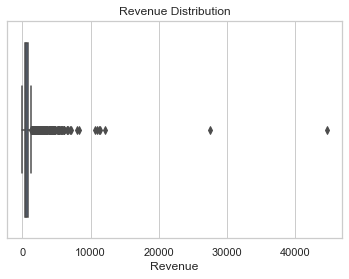

In [148]:
sns.boxplot(x=df['Revenue'])
plt.title('Revenue Distribution')
plt.show()

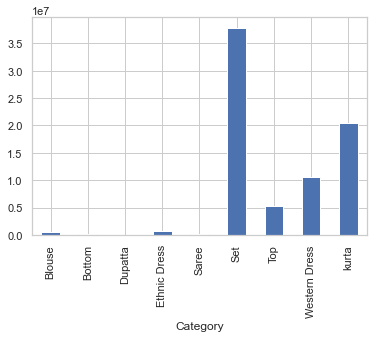

In [60]:
df.groupby('Category')['Revenue'].sum().plot(kind='bar')
plt.show()

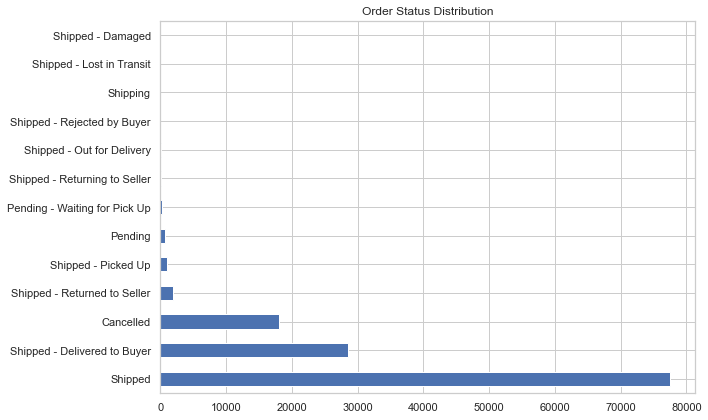

In [101]:
plt.figure(figsize=(10,6))

df['Status'].value_counts().plot(kind='barh')

plt.title("Order Status Distribution")
plt.tight_layout()
plt.show()

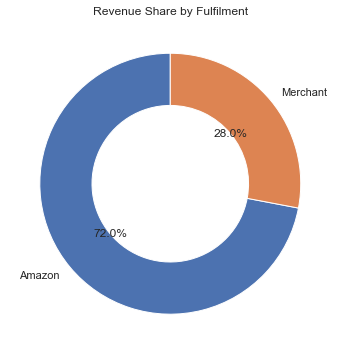

In [102]:
plt.figure(figsize=(6,6))

data = df.groupby('Fulfilment')['Revenue'].sum()

plt.pie(data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4})

plt.title('Revenue Share by Fulfilment')
plt.show()

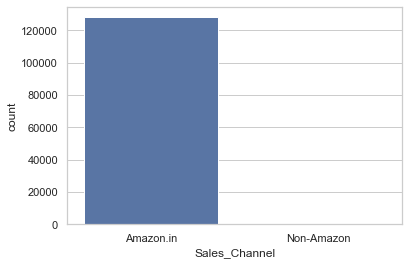

In [63]:
sns.countplot(x='Sales_Channel', data=df)
plt.show()

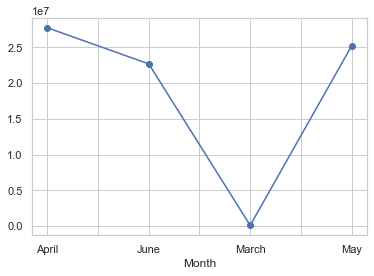

In [64]:
df.groupby('Month')['Revenue'].sum().plot(kind='line', marker='o')
plt.show()

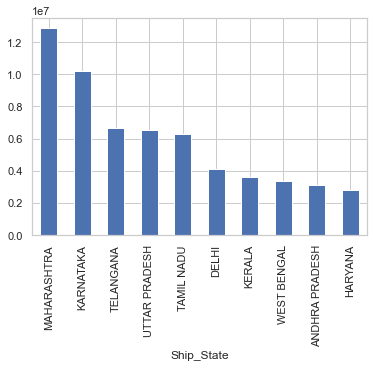

In [65]:
df.groupby('Ship_State')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

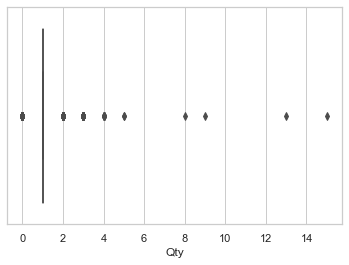

In [66]:
sns.boxplot(x=df['Qty'])
plt.show()

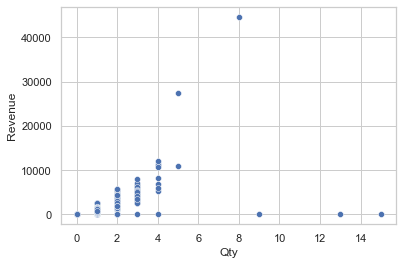

In [67]:
sns.scatterplot(x='Qty', y='Revenue', data=df)
plt.show()

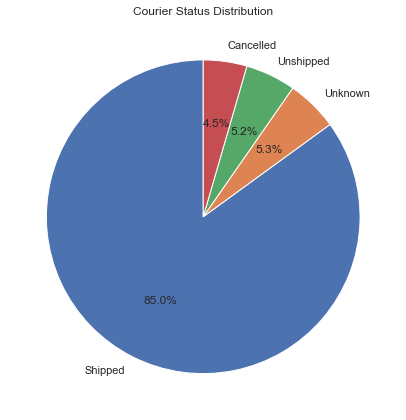

In [143]:
plt.figure(figsize=(6,6))

vals = df['Courier_Status'].value_counts()

plt.pie(
    vals,
    labels=vals.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Courier Status Distribution')
plt.tight_layout()
plt.show()

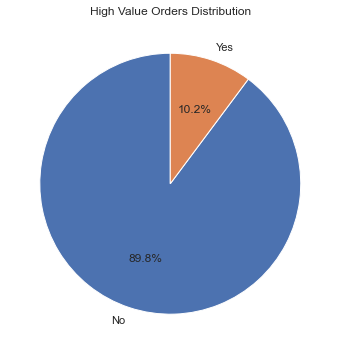

In [103]:
plt.figure(figsize=(6,6))

data = df['High_Value_Order'].value_counts()

plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title('High Value Orders Distribution')
plt.show()

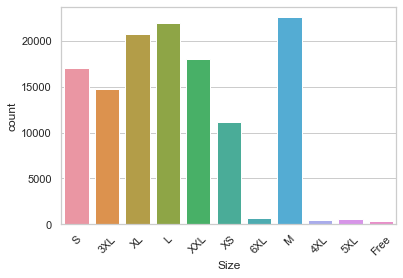

In [70]:
sns.countplot(x='Size', data=df)
plt.xticks(rotation=45)
plt.show()

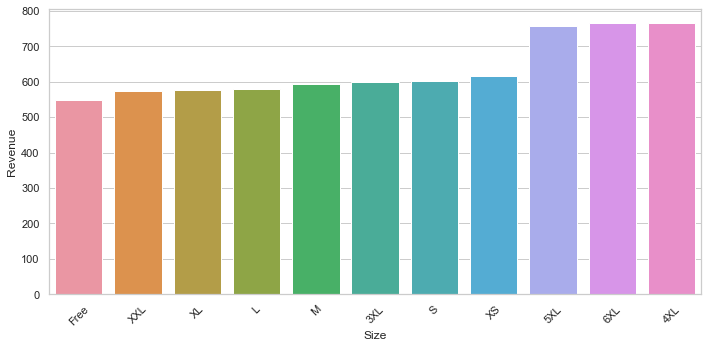

In [142]:
plt.figure(figsize=(10,5))

order = df.groupby('Size')['Revenue'].mean().sort_values().index

sns.barplot(
    x='Size',
    y='Revenue',
    data=df,
    order=order,
    ci=None
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

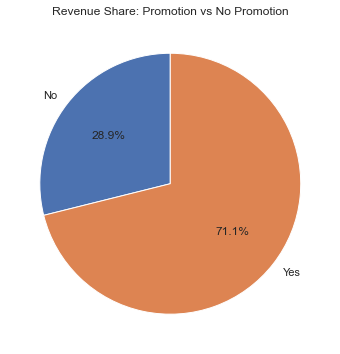

In [104]:
plt.figure(figsize=(6,6))

data = df.groupby('Promotion_Used')['Revenue'].sum()

plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title('Revenue Share: Promotion vs No Promotion')
plt.show()

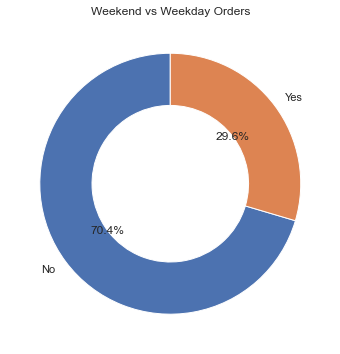

In [105]:
plt.figure(figsize=(6,6))

data = df['Weekend'].value_counts()

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title('Weekend vs Weekday Orders')
plt.show()

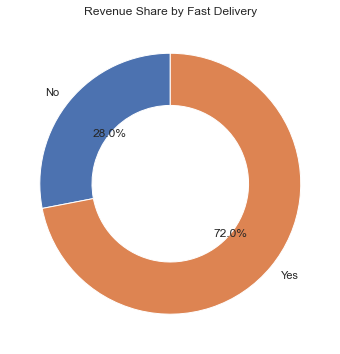

In [107]:
plt.figure(figsize=(6,6))

data = df.groupby('Fast_Delivery')['Revenue'].sum()

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title('Revenue Share by Fast Delivery')
plt.show()

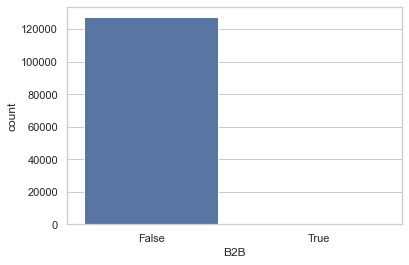

In [75]:
sns.countplot(x='B2B', data=df)
plt.show()

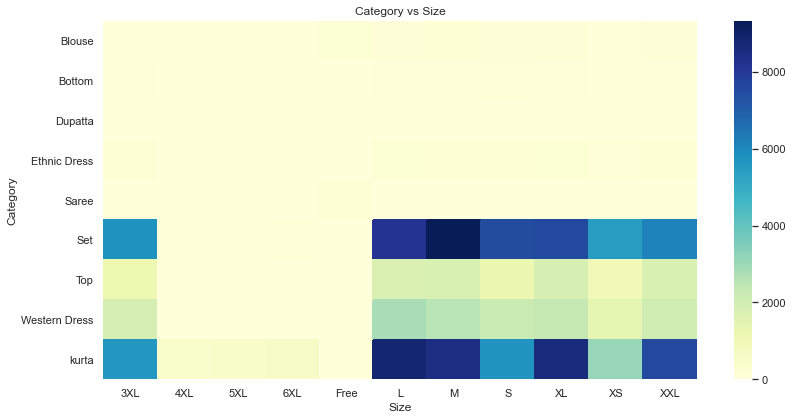

In [141]:
plt.figure(figsize=(12,6))

pivot = pd.crosstab(df['Category'], df['Size'])

sns.heatmap(pivot, cmap='YlGnBu')

plt.title('Category vs Size')
plt.tight_layout()
plt.show()

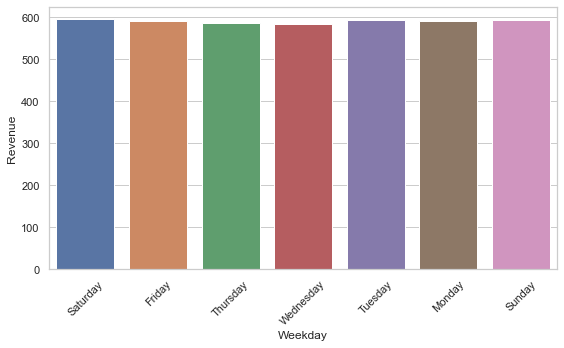

In [140]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Weekday',
    y='Revenue',
    data=df,
    ci=None
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

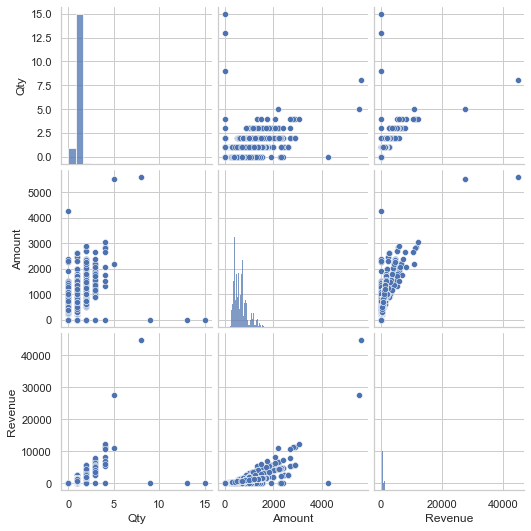

In [78]:
sns.pairplot(df[['Qty','Amount','Revenue']])
plt.show()

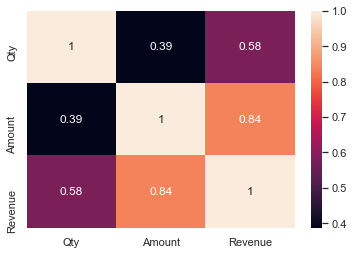

In [79]:
sns.heatmap(df[['Qty','Amount','Revenue']].corr(), annot=True)
plt.show()

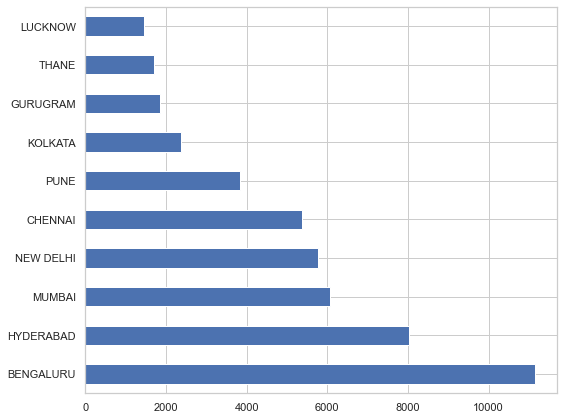

In [110]:
plt.figure(figsize=(8,6))
df['Ship_City'].value_counts().head(10).plot(kind='barh')
plt.tight_layout()
plt.show()

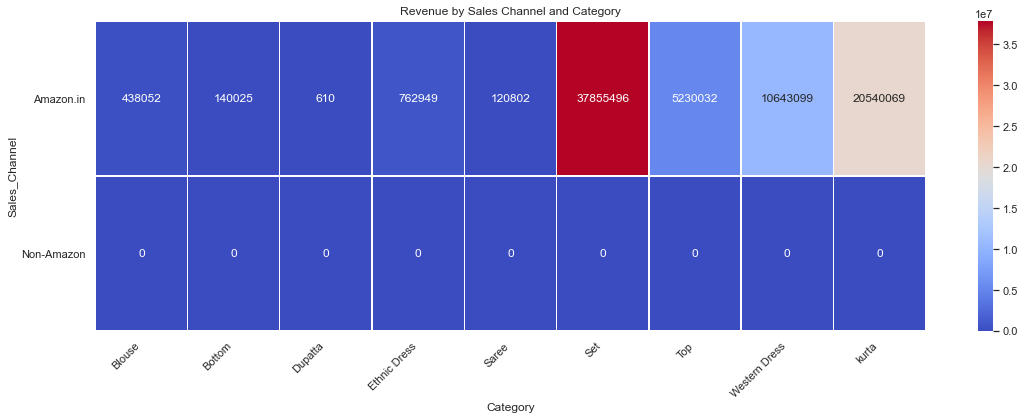

In [112]:
plt.figure(figsize=(16,6))

pivot = df.pivot_table(
    values='Revenue',
    index='Sales_Channel',
    columns='Category',
    aggfunc='sum'
).fillna(0)

sns.heatmap(
    pivot,
    cmap='coolwarm',
    annot=True,
    fmt='.0f',
    linewidths=0.5
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Revenue by Sales Channel and Category')

plt.tight_layout()
plt.show()

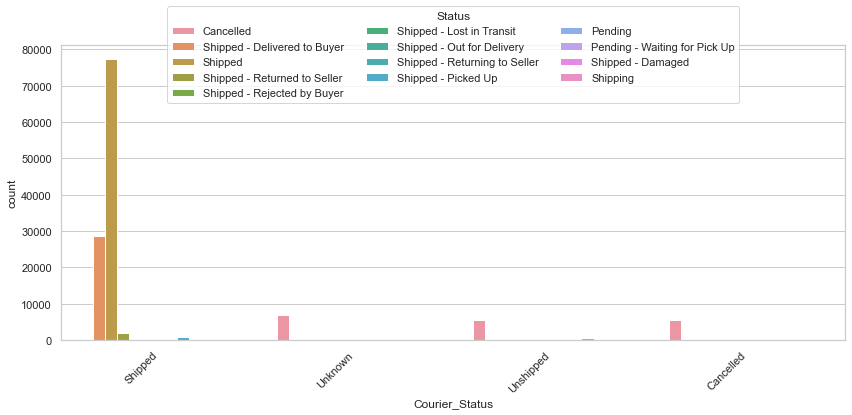

In [118]:
plt.figure(figsize=(12,6))

order = df['Courier_Status'].value_counts().index

sns.countplot(
    x='Courier_Status',
    hue='Status',
    data=df,
    order=order
)

plt.xticks(rotation=45, ha='right')

plt.legend(title='Status', bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=3)
plt.tight_layout()
plt.show()

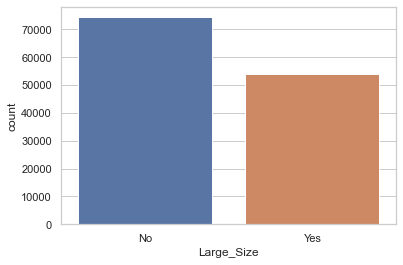

In [85]:
sns.countplot(x='Large_Size', data=df)
plt.show()

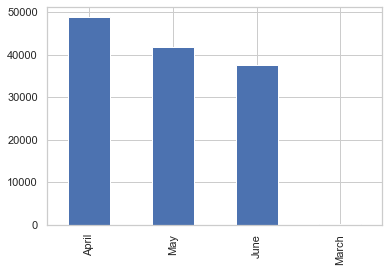

In [86]:
df['Month'].value_counts().plot(kind='bar')
plt.show()

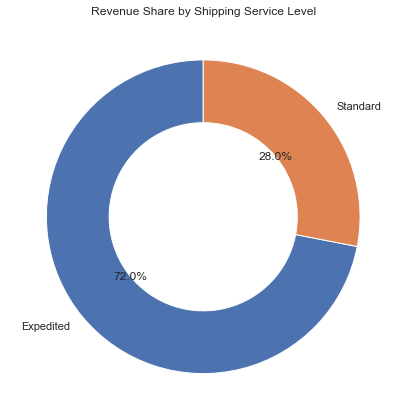

In [120]:
plt.figure(figsize=(6,6))

pivot = df.groupby('Ship_Service_Level')['Revenue'].sum()

plt.pie(
    pivot,
    labels=pivot.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Revenue Share by Shipping Service Level')
plt.tight_layout()
plt.show()

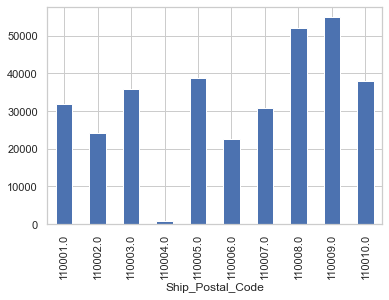

In [88]:
df.groupby('Ship_Postal_Code')['Revenue'].sum().head(10).plot(kind='bar')
plt.show()

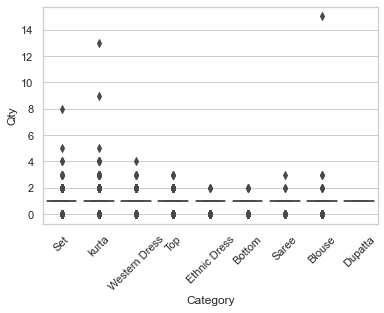

In [89]:
sns.boxplot(x='Category', y='Qty', data=df)
plt.xticks(rotation=45)
plt.show()

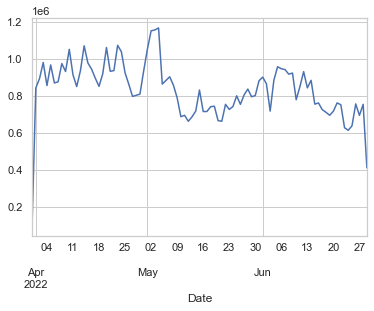

In [90]:
df.groupby('Date')['Revenue'].sum().plot()
plt.show()

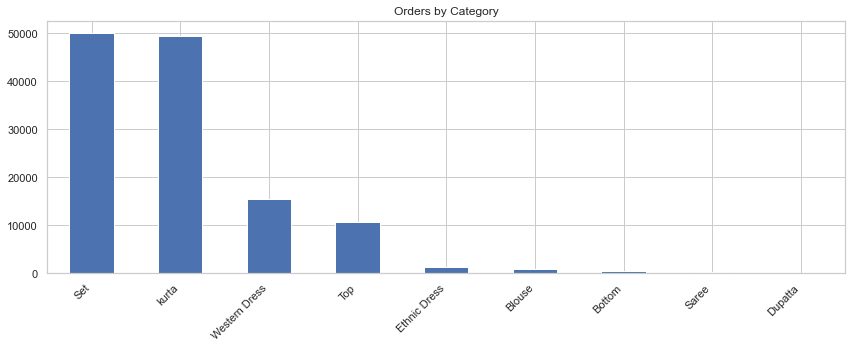

In [121]:
plt.figure(figsize=(12,5))

df['Category'].value_counts().plot(kind='bar')

plt.xticks(rotation=45, ha='right')
plt.title("Orders by Category")

plt.tight_layout()
plt.show()

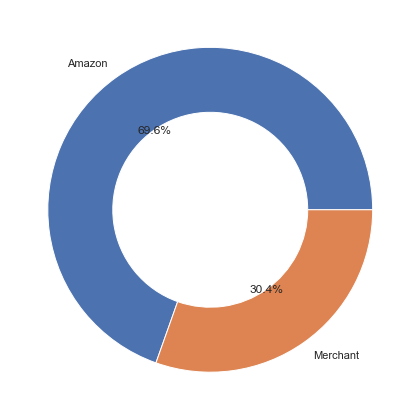

In [122]:
vals = df['Fulfilment'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    vals,
    labels=vals.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4)
)

plt.tight_layout()
plt.show()

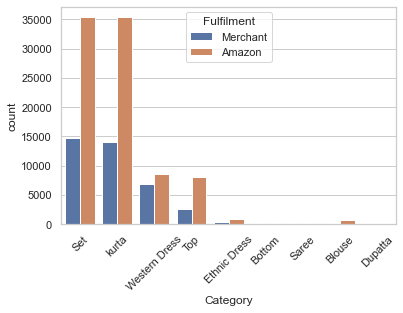

In [93]:
sns.countplot(x='Category', hue='Fulfilment', data=df)
plt.xticks(rotation=45)
plt.show()

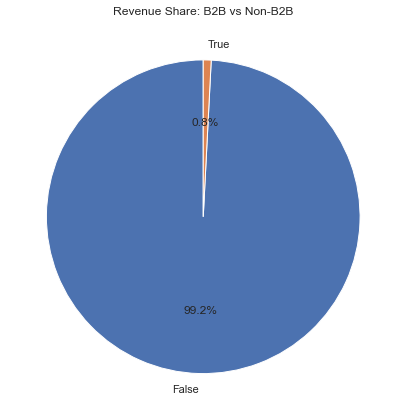

In [137]:
plt.figure(figsize=(6,6))

pivot = df.groupby('B2B')['Revenue'].sum()

plt.pie(
    pivot,
    labels=pivot.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Revenue Share: B2B vs Non-B2B')
plt.tight_layout()
plt.show()

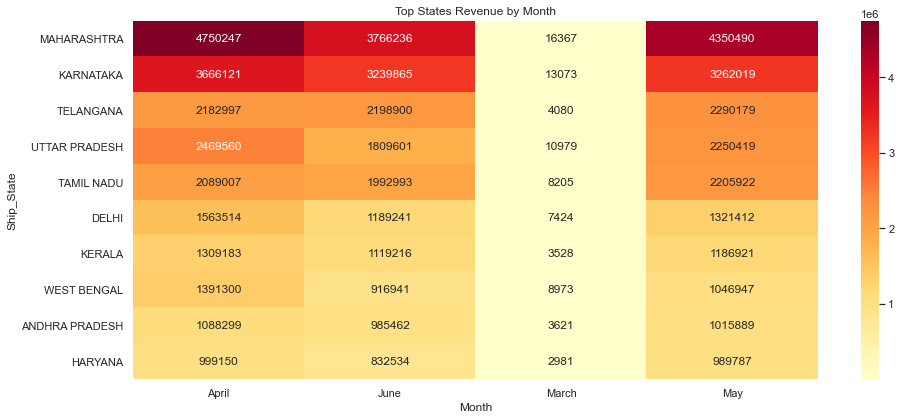

In [126]:
plt.figure(figsize=(14,6))

pivot = df.pivot_table(
    values='Revenue',
    index='Ship_State',
    columns='Month',
    aggfunc='sum'
).fillna(0)

top_states = pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot = pivot.loc[top_states]

sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f')

plt.title('Top States Revenue by Month')
plt.tight_layout()
plt.show()

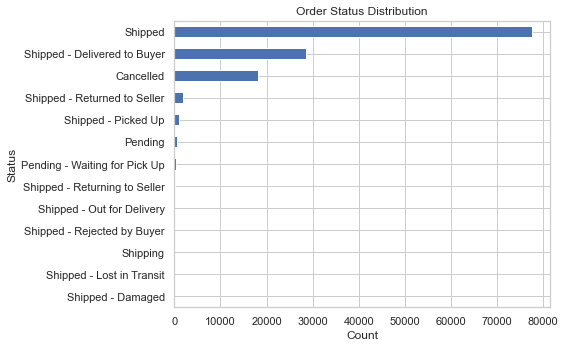

In [129]:
plt.figure(figsize=(8,5))

df['Status'].value_counts().sort_values().plot(kind='barh')

plt.xlabel("Count")
plt.ylabel("Status")
plt.title("Order Status Distribution")

plt.tight_layout()
plt.show()

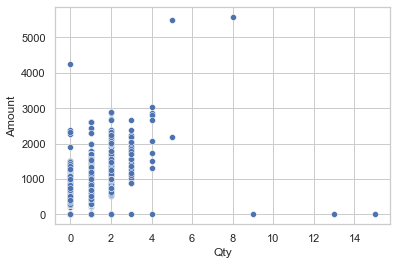

In [97]:
sns.scatterplot(x='Qty', y='Amount', data=df)
plt.show()

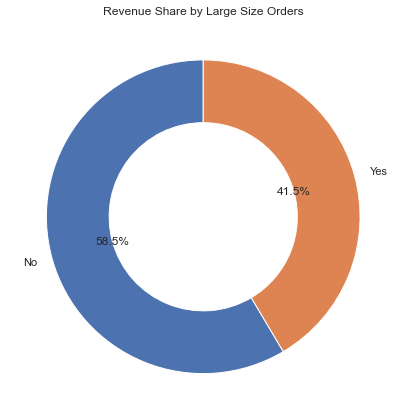

In [131]:
plt.figure(figsize=(6,6))

pivot = df.groupby('Large_Size')['Revenue'].sum()

plt.pie(
    pivot,
    labels=pivot.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Revenue Share by Large Size Orders')
plt.tight_layout()
plt.show()

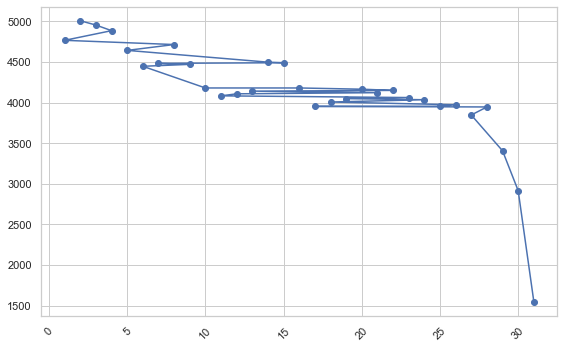

In [136]:
vals = df['Day'].value_counts()

plt.figure(figsize=(8,5))
plt.plot(vals.index, vals.values, marker='o')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

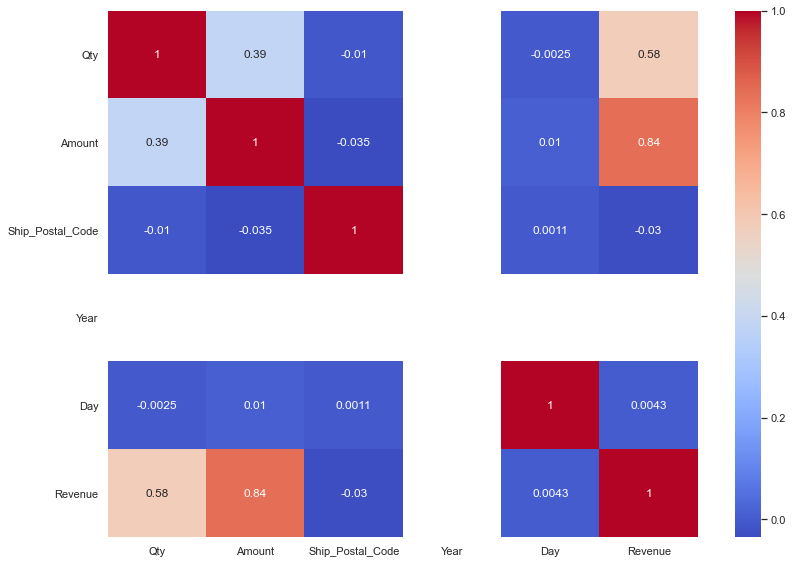

In [152]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.tight_layout()
plt.show()

In [154]:
df.to_csv("Amazon_sales.csv", index=False)